=== SUMMARY ===
          btc_volume  days_to_holiday
count     365.000000       365.000000
mean    19777.218118         7.309589
std     12185.233765         5.454108
min      3104.117220         0.000000
25%     12232.440420         3.000000
50%     17661.275100         6.000000
75%     23706.497990        11.000000
max    106298.828990        23.000000

=== SPEARMAN CORRELATION ===
Correlation: 0.079107
P-value: 0.131424


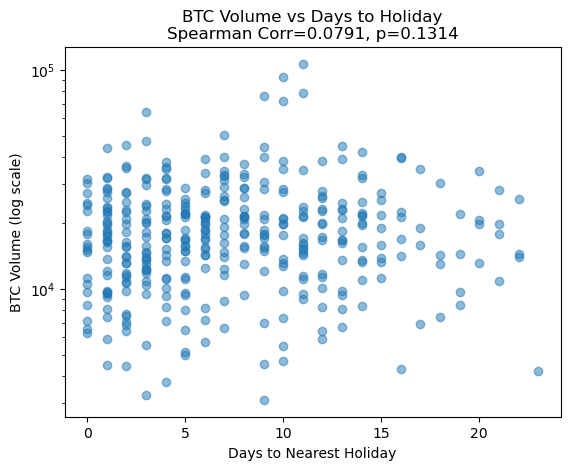


=== INTERPRETATION ===
There is NO statistically significant relationship.
BTC volume tends to DECREASE as holidays get closer.
The relationship is very weak.


In [16]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

# -------------------------------
# Load dataset
# -------------------------------
file_path = "data/gold/btc_fng_with_holidays_api.csv"  # change if needed
df = pd.read_csv(file_path, parse_dates=["date"])

# -------------------------------
# Prepare data
# -------------------------------
df = df[["btc_volume", "days_to_holiday"]].copy()

# Clean data
df["btc_volume"] = pd.to_numeric(df["btc_volume"], errors="coerce")
df["days_to_holiday"] = pd.to_numeric(df["days_to_holiday"], errors="coerce")
df = df.dropna()

# -------------------------------
# Spearman correlation
# -------------------------------
corr, p_value = spearmanr(df["days_to_holiday"], df["btc_volume"])

# -------------------------------
# Summary statistics
# -------------------------------
print("=== SUMMARY ===")
print(df.describe())

# -------------------------------
# Correlation results
# -------------------------------
print("\n=== SPEARMAN CORRELATION ===")
print(f"Correlation: {corr:.6f}")
print(f"P-value: {p_value:.6f}")

# -------------------------------
# Visualization (Correlation Chart)
# -------------------------------
plt.figure()

plt.scatter(df["days_to_holiday"], df["btc_volume"], alpha=0.5)

# Log scale (recommended for BTC volume)
plt.yscale("log")

plt.xlabel("Days to Nearest Holiday")
plt.ylabel("BTC Volume (log scale)")
plt.title(f"BTC Volume vs Days to Holiday\nSpearman Corr={corr:.4f}, p={p_value:.4f}")

plt.show()

# -------------------------------
# Interpretation
# -------------------------------
print("\n=== INTERPRETATION ===")

# Significance
if p_value < 0.05:
    print("There is a statistically significant relationship.")
else:
    print("There is NO statistically significant relationship.")

# Direction
if corr < 0:
    print("BTC volume tends to INCREASE as holidays get closer.")
elif corr > 0:
    print("BTC volume tends to DECREASE as holidays get closer.")
else:
    print("No meaningful relationship between variables.")

# Strength
abs_corr = abs(corr)
if abs_corr < 0.1:
    strength = "very weak"
elif abs_corr < 0.3:
    strength = "weak"
elif abs_corr < 0.5:
    strength = "moderate"
else:
    strength = "strong"

print(f"The relationship is {strength}.")

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

# ── Load dataset ───────────────────────────────────────────────────────────────
df = pd.read_csv("btc_fng_with_holidays_api.csv", parse_dates=["date"])

# ── Prepare data ───────────────────────────────────────────────────────────────
df = df.drop_duplicates(subset="date").sort_values("date").reset_index(drop=True)
df = df[["date", "btc_volume", "days_to_holiday"]].copy()

df["btc_volume"]      = pd.to_numeric(df["btc_volume"],      errors="coerce")
df["days_to_holiday"] = pd.to_numeric(df["days_to_holiday"], errors="coerce")
df = df.dropna()

# ── Spearman correlation ───────────────────────────────────────────────────────
corr, p_value = spearmanr(df["days_to_holiday"], df["btc_volume"])

# ── Summary statistics ─────────────────────────────────────────────────────────
print("=== SUMMARY ===")
print(df[["btc_volume", "days_to_holiday"]].describe().round(2))

# ── Correlation results ────────────────────────────────────────────────────────
print("\n=== SPEARMAN CORRELATION ===")
print(f"Correlation: {corr:.6f}")
print(f"P-value:     {p_value:.6f}")

# ── Visualization ──────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6), facecolor="#f8f8f6")
ax.set_facecolor("#f8f8f6")

ax.scatter(df["days_to_holiday"], df["btc_volume"],
           alpha=0.5, color="#3266ad", edgecolors="#185fa5", linewidths=0.4, s=40)

ax.set_yscale("log")
ax.set_xlabel("Days to nearest holiday", fontsize=12)
ax.set_ylabel("BTC volume (log scale)", fontsize=12)
ax.set_title(f"BTC volume vs days to holiday\nSpearman r = {corr:.4f},  p = {p_value:.4f}",
             fontsize=13, fontweight="bold")
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("btc_volume_spearman.png", dpi=150, bbox_inches="tight", facecolor="#f8f8f6")
print("\nChart saved: btc_volume_spearman.png")

# ── Interpretation ─────────────────────────────────────────────────────────────
print("\n=== INTERPRETATION ===")

if p_value < 0.05:
    print("There IS a statistically significant relationship.")
else:
    print("There is NO statistically significant relationship.")

if corr < 0:
    print("BTC volume tends to INCREASE as holidays get closer.")
elif corr > 0:
    print("BTC volume tends to DECREASE as holidays get closer.")
else:
    print("No meaningful direction detected.")

abs_corr = abs(corr)
if abs_corr < 0.1:    strength = "very weak"
elif abs_corr < 0.3:  strength = "weak"
elif abs_corr < 0.5:  strength = "moderate"
else:                 strength = "strong"

print(f"Relationship strength: {strength} (|r| = {abs_corr:.4f})")

FileNotFoundError: [Errno 2] No such file or directory: 'btc_fng_with_holidays_api.csv'